# Modelling: predicting London Heathrow daily sunshine

The goal of this notebook is to:
- Predict the hours of sunshine on a given day from that day's other weather data,
- Compare the performance of models when exposed to different engineered features.

This notebook will:
- Build a pipeline to bundle preprocessing and modelling.
- Experiment with different features, including KMeans clustering.
- Build, train, test a Random Forest Regression model and a Gradient Boost model.
- Predict the daily hours of sunshine at London Heathrow.
- Perform analysis on the effects of temporal leakage.
- Give thoughts and reflections.

## 1. Setup

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from data import load_raw, clean
from features import add_lag_features, add_season, add_seasonal_interactions
from models import RFR_score, cv_score

FIGURES = '../notebooks/figures'
MODELS = '../models'

df = clean(load_raw())

# Build the lag-augmented and season-augmented base frame once
X = df.drop(columns=['sunshine'])
y = df['sunshine']
X, y = add_lag_features(X, y)
X = add_season(X)
X = X.drop(columns=['date'])   # date is not a model feature

print(f'X shape: {X.shape}')
print(f'columns: {list(X.columns)}')

X shape: (15312, 14)
columns: ['cloud_cover', 'global_radiation', 'max_temp', 'mean_temp', 'min_temp', 'precipitation', 'pressure', 'snow_depth', 'sunshine_lag_1', 'sunshine_lag_2', 'Autumn', 'Spring', 'Summer', 'Winter']


## 2. Baseline scores to judge our models perfomance

We can determine whether our machine learning models are worth running by comparing their results to a basic calculation, and use that as the floor to measure performance.

In this case we'll use two guesses;
1) Using yesterday's sunshine as an indicator of today's sunshine. Extremely basic, just calculate the average of the difference between yesterdays sunshine and todays.

2) Use the historical seasonal mean as the forecast for today's sunshine.

Both methods scored using the same TimeSeriesSplit() the model will use since for it to be a fair comparison they need to be evaluated on the same folds as the model.

If the models can't beat these tests significantly, the computing power required for the machine learning models cannot be reasonably justified.

In [2]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error

tscv = TimeSeriesSplit(n_splits=5)

# Predict yesterday baseline: y_pred for row i = y_lag_1 for row i
yesterday_maes = []
for train_idx, test_idx in tscv.split(X):
    y_pred = X.iloc[test_idx]['sunshine_lag_1']
    y_true = y.iloc[test_idx]
    yesterday_maes.append(mean_absolute_error(y_true, y_pred))

# Predict seasonal mean baseline: fit per fold on training rows, predict each test row's season mean
season_cols = ['Spring', 'Summer', 'Autumn', 'Winter']
seasonal_mean_maes = []
for train_idx, test_idx in tscv.split(X):
    train_season = X.iloc[train_idx][season_cols].idxmax(axis=1)
    test_season = X.iloc[test_idx][season_cols].idxmax(axis=1)
    season_means = y.iloc[train_idx].groupby(train_season).mean()
    y_pred = test_season.map(season_means)
    y_true = y.iloc[test_idx]
    seasonal_mean_maes.append(mean_absolute_error(y_true, y_pred))

print(f'Predict yesterday      MAE: {np.mean(yesterday_maes):.3f} hrs')
print(f'Predict seasonal mean  MAE: {np.mean(seasonal_mean_maes):.3f} hrs')

Predict yesterday      MAE: 3.184 hrs
Predict seasonal mean  MAE: 3.080 hrs


## 3. The effects of Temporal Data Leakage on Model Performance

TimeSeriesSplit() is needed to cross validate correctly for this dataset.
- Given that the dataset is a time series, we can't blindly use the [cross_val_score()](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html) scoring function as this defaults to the KFold cross validation splitting strategy.
- The [KFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html#) splitting strategy is random, meaning that chunks of data from say 2015 would be used to train the model first, and then the model would be tested on data from much earlier, eg 1990s data. This would perturb the testing scores given the access to future information.
- [TimeSeriesSplit()](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html#) handles splitting the train/test sets for time ordered data without training on future data and evaluating on past data.

We can compare how the same model performs with the temporal leakage from the KFold random splitting with an aditional global mean missing value imputation (which is further leakage given that the mean is calculated on future data) against a clean pipeline methodology with TimeSeriesSplit() inside of the cv_score() cross validator.

In [3]:
# Temporal leakage flow: mean impute the whole frame up front, then KFold-score.
X_old = pd.DataFrame(
    SimpleImputer(strategy='mean').fit_transform(X),
    columns=X.columns,
    index=X.index,
)
old_mae, _ = RFR_score(X_old, y)

# Leak free flow: pipeline imputes per fold, TimeSeriesSplit for cross validation.
rf_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='mean')),
    ('model',  RandomForestRegressor(random_state=1)),
])
new_mae, new_fold_maes = cv_score(rf_pipe, X, y)

print(f'With Temporal Leakage   MAE: {old_mae:.3f} hrs    (=  {old_mae*60:.0f} minutes)')
print(f'Without Temporal Leakage MAE: {new_mae:.3f} hrs (with fold std ±{new_fold_maes.std():.3f})    (=  {new_mae*60:.0f} minutes)')
print(f'Effects of the leakage:  {new_mae - old_mae:+.3f} hrs    ({(new_mae - old_mae)*60:+.0f} minutes)')

With Temporal Leakage   MAE: 0.749 hrs    (=  45 minutes)
Without Temporal Leakage MAE: 0.773 hrs (with fold std ±0.044)    (=  46 minutes)
Effects of the leakage:  +0.023 hrs    (+1 minutes)


## 4. Feature engineering sweep
- Seasons added using a date filter and one hot encoding.
    - This means that each row has four additional columns, one for each season. The value is 1 if the row is in that season, 0 otherwise. E.g. Winter=1, Spring=0, Summer=0, Autumn=0

- Seasonal interactions, to "seasonalise" the features.
    - Features are multiplied by the one hot encoded season columns, ie multiplied by 1 or 0.
    - X[f'{feature}_winter'] = df[feature] * df['Winter'] for all seasons for all features.
    - This is a direct attempt to tell the model that the features behave differently for different seasons.

- KMeans clustering algorithm.
    - Will be discussed below

In [4]:
# Build the six feature frames
X_base = X.drop(columns=season_cols).copy()                              # no seasons
X_seasons = X.copy()                                                     # with seasons

base_features = [c for c in X_base.columns if not c.startswith('sunshine_lag')]
X_interactions = add_seasonal_interactions(X.copy(), base_features)      # seasons + interactions

feature_frames = {
    'Baseline (no seasons)':       X_base,
    'With seasons':                X_seasons,
    'With seasonal interactions':  X_interactions,
}

## 5. KMeans clustering

[KMeans](https://scikit-learn.org/stable/modules/clustering.html#k-means) is an unsupervised clustering algorithm.

It works by:
- Firstly, taking in a table of normalised numbers and an integer k. 
- Secondly, it places k points, called centroids, in the numeric space of the table. 
- Thirdly, it evaluates every row in the frame and assigns it to its nearest centroid. 
- Finally, it then moves each centroid to the average position of the rows assigned to that centroid. This process is then iterated until there is no movement, outputting k clusters where each row in the input dataframe belongs to its numerically closest cluster. 
There are then two output methods of the algorithm:
- .predict() - This creates a new column, assigning each row to its nearest centroid via a label.
- .transform() - This outputs the distance from every row, to every centroid; an (n_rows,n_clusters) matrix of distances.

I'm including it to see if the weather falls into subsets of "types" of days, like warm with a breeze, rain with wind etc, that could be picked up by a clustering algorithm such as this one. This is pretty unlikely but it could be worth trying, a regressor would apreciate these categories of days if they exist.

To properly decide upon a value of k, we can fit KMeans for a range of different k and look at two markers of its performance; the inertia and the [silhouette score](https://scikit-learn.org/stable/modules/clustering.html#silhouette-coefficient).
- The inertia is the total squared difference of every row from its assigned centroid, this is what the algorithm is minimising during its iterations. Logically it will drop with every aditional cluster, so instead we look for an "elbow" shape where the inertia stops falling rapidly.
- The silhoutte coefficient, this scores each row on a scale from -1 to +1, where -1 means the row is in the incorrect cluster, 0 means on the bondary of two clusters, and +1 means very close to the centroid. This is calculated as $s = \frac{b - a}{max(a, b)}$ , where a = the mean distance betwwen a sample and all other points in the same class, b = the mean distance between a sample and all other points in the nearest cluster. The silhouette score averages across the silhouette coefficients.

  k= 2  inertia=11687.7  silhouette=0.259
  k= 3  inertia=9699.2  silhouette=0.269
  k= 4  inertia=8000.3  silhouette=0.257
  k= 5  inertia=6874.0  silhouette=0.256
  k= 6  inertia=6003.3  silhouette=0.237
  k= 7  inertia=5317.3  silhouette=0.242
  k= 8  inertia=4942.8  silhouette=0.246
  k= 9  inertia=4647.7  silhouette=0.217
  k=10  inertia=4280.8  silhouette=0.223


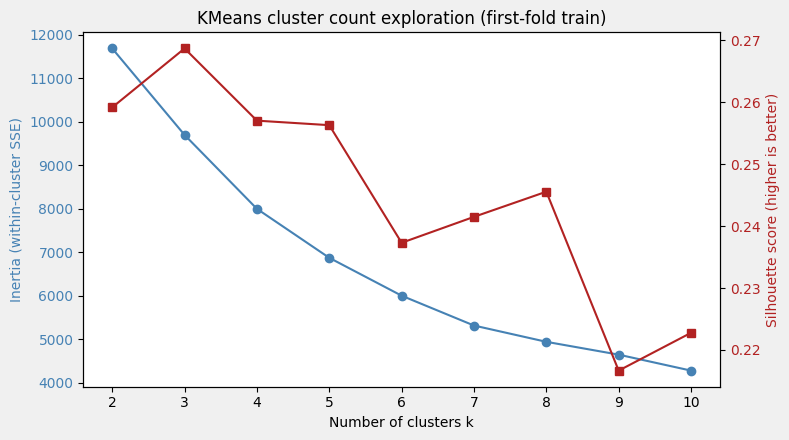

In [5]:
from sklearn.metrics import silhouette_score

# features to cluster on
kmeans_features = ['cloud_cover', 'global_radiation', 'max_temp',
                   'precipitation', 'pressure', 'snow_depth']

# fit on the first training fold only to avoid leakage
first_train_idx, _ = next(tscv.split(X))

# smol pipeline to impute and normalise
prep = Pipeline([('impute', SimpleImputer(strategy='mean')),
                 ('scale',  StandardScaler())])
X_train_scaled = prep.fit_transform(X[kmeans_features].iloc[first_train_idx])

# 2000 random row indicies
rng = np.random.default_rng(0)
sample_idx = rng.choice(X_train_scaled.shape[0], size=2000, replace=False)

# fit and score
ks = list(range(2, 11))
inertias, silhouettes = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X_train_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_train_scaled[sample_idx], km.labels_[sample_idx]))
    print(f'  k={k:2d}  inertia={km.inertia_:.1f}  silhouette={silhouettes[-1]:.3f}')

# double axis plot so both metrics share the x axis
fig, ax1 = plt.subplots(figsize=(8, 4.5))
fig.set_facecolor('#f0f0f0')
ax1.plot(ks, inertias, marker='o', color='steelblue', label='inertia')
ax1.set_xlabel('Number of clusters k')
ax1.set_ylabel('Inertia (within-cluster SSE)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(ks, silhouettes, marker='s', color='firebrick', label='silhouette')
ax2.set_ylabel('Silhouette score (higher is better)', color='firebrick')
ax2.tick_params(axis='y', labelcolor='firebrick')

ax1.set_title('KMeans cluster count exploration (first-fold train)')
ax1.set_xticks(ks)
fig.tight_layout()
fig.savefig(f'{FIGURES}/kmeans_elbow.png', dpi=120, bbox_inches='tight')
plt.show()

*Thoughts*
- No elbow shape seen in the inertia readings which is discouraging. The biggest gradient change is at k = 4.
- The silhouette scores k = 2 and k = 4 highest.
- Now given that there are four seasons, this is probably what the clustering algorithm is picking up.
- k = 8 is interesting, despite there not being a significant inertia change, the silhouette score performs almost as well as k = 2 and 4, and far better than its adjacent values of k = 7 and 9. This could be worth looking at, simply for the fact that 8 clusters might present differently to the four season method of thinking. I will include it out of curiosity.

In [6]:
# Applying KMeans.transform() - for each row, KMeans gives us its distances to every centroid. 
# e.g. for k=2 clusters, every row gets k new columns:[distance to centroid 1],[distance to centroid 2].

# Using a pipeline to be safe, without it I'd have to refit the imputer, scaler and kmeans
# on each fold.
from sklearn.compose import ColumnTransformer

def make_kmeans_feature_block(input_columns, cluster_features, n_clusters):
    """ColumnTransformer that emits [all imputed cols] + [k centroid-distance cols]."""
    # ColumnTransformer runs several preprocessing branches in parallel, then concatenates outputs.
    return ColumnTransformer(
        transformers=[
            # This branch takes every column in input_columns and imputes missing values
            ('keep', SimpleImputer(strategy='mean'), input_columns),
            # This branch takes the cluster features, then runs them through the pipeline that
            # includes our kmeans algo
            ('clusters', Pipeline([
                ('impute', SimpleImputer(strategy='mean')),
                ('scale',  StandardScaler()),
                ('kmeans', KMeans(n_clusters=n_clusters, n_init=10, random_state=0)),
            ]), cluster_features),
        ],
        # No need to call .transform() directly; when the pipeline runs fit, every (non final) 
        # step has its .transform() called to feed the next step of the pipeline anyway.
        remainder='drop',
    )
    # output for pipelines below: [all raw columns] + [k distance columns].

def make_kmeans_rf_pipe(input_columns, n_clusters):
    return Pipeline([
        ('features', make_kmeans_feature_block(input_columns, kmeans_features, n_clusters)),
        ('model',    RandomForestRegressor(random_state=1)),
    ])

def make_kmeans_xgb_pipe(input_columns, n_clusters):
    return Pipeline([
        ('features', make_kmeans_feature_block(input_columns, kmeans_features, n_clusters)),
        ('model',    XGBRegressor(random_state=0, n_estimators=300, learning_rate=0.1, n_jobs=4)),
    ])

# values of k to test
candidate_ks = [2, 4, 8]

# save the relevant df for each k, so that it can be scored with and without seasons
kmeans_variants = {}
for k in candidate_ks:
    kmeans_variants[f'KMeans({k}) + raw, no seasons'] = dict(frame=X_base,    n_clusters=k)
    kmeans_variants[f'KMeans({k}) + raw, seasons']    = dict(frame=X_seasons, n_clusters=k)

# adding on an include everything frame, k=2 with seasons and seasonal interactions
kmeans_variants['KMeans(2) + raw, seasons + interactions'] = dict(
    frame=X_interactions, n_clusters=2,
)

# Check registration
print('KMeans variants registered:')
for name, cfg in kmeans_variants.items():
    print(f'  {name:42s} frame_shape={cfg["frame"].shape}  n_clusters={cfg["n_clusters"]}')

KMeans variants registered:
  KMeans(2) + raw, no seasons                frame_shape=(15312, 10)  n_clusters=2
  KMeans(2) + raw, seasons                   frame_shape=(15312, 14)  n_clusters=2
  KMeans(4) + raw, no seasons                frame_shape=(15312, 10)  n_clusters=4
  KMeans(4) + raw, seasons                   frame_shape=(15312, 14)  n_clusters=4
  KMeans(8) + raw, no seasons                frame_shape=(15312, 10)  n_clusters=8
  KMeans(8) + raw, seasons                   frame_shape=(15312, 14)  n_clusters=8
  KMeans(2) + raw, seasons + interactions    frame_shape=(15312, 46)  n_clusters=2


## 6. Build and run models


In [7]:
# Plain feature_frames use a simple impute+model pipeline.
# kmeans_variants uses a ColumnTransformer based pipeline that
# refits imputer, scaler and KMeans per fold.

def make_rf_pipe():
    return Pipeline([('impute', SimpleImputer(strategy='mean')),
                     ('model',  RandomForestRegressor(random_state=1))])

def make_xgb_pipe():
    return Pipeline([('impute', SimpleImputer(strategy='mean')),
                     ('model',  XGBRegressor(random_state=0,
                                             n_estimators=300,
                                             learning_rate=0.1,
                                             n_jobs=4))])

results = []

# Plain configs
for name, frame in feature_frames.items():
    rf_mae,  rf_folds  = cv_score(make_rf_pipe(),  frame, y)
    xgb_mae, xgb_folds = cv_score(make_xgb_pipe(), frame, y)
    results.append({'Features': name, 'Model': 'Random Forest', 'MAE': rf_mae,  'MAE_std': rf_folds.std()})
    results.append({'Features': name, 'Model': 'XGBoost',       'MAE': xgb_mae, 'MAE_std': xgb_folds.std()})
    print(f'{name:36s}  RF={rf_mae:.3f} (±{rf_folds.std():.3f})  XGB={xgb_mae:.3f} (±{xgb_folds.std():.3f})')

# KMeans configs 
for name, cfg in kmeans_variants.items():
    frame = cfg['frame']
    k     = cfg['n_clusters']
    rf_mae,  rf_folds  = cv_score(make_kmeans_rf_pipe(list(frame.columns), k),  frame, y)
    xgb_mae, xgb_folds = cv_score(make_kmeans_xgb_pipe(list(frame.columns), k), frame, y)
    results.append({'Features': name, 'Model': 'Random Forest', 'MAE': rf_mae,  'MAE_std': rf_folds.std()})
    results.append({'Features': name, 'Model': 'XGBoost',       'MAE': xgb_mae, 'MAE_std': xgb_folds.std()})
    print(f'{name:36s}  RF={rf_mae:.3f} (±{rf_folds.std():.3f})  XGB={xgb_mae:.3f} (±{xgb_folds.std():.3f})')

results_df = pd.DataFrame(results)

Baseline (no seasons)                 RF=0.874 (±0.046)  XGB=0.877 (±0.037)
With seasons                          RF=0.773 (±0.044)  XGB=0.755 (±0.036)
With seasonal interactions            RF=0.758 (±0.041)  XGB=0.746 (±0.031)
KMeans(2) + raw, no seasons           RF=0.873 (±0.046)  XGB=0.880 (±0.041)
KMeans(2) + raw, seasons              RF=0.776 (±0.044)  XGB=0.759 (±0.036)
KMeans(4) + raw, no seasons           RF=0.876 (±0.046)  XGB=0.878 (±0.038)
KMeans(4) + raw, seasons              RF=0.776 (±0.044)  XGB=0.758 (±0.033)
KMeans(8) + raw, no seasons           RF=0.873 (±0.042)  XGB=0.881 (±0.040)
KMeans(8) + raw, seasons              RF=0.779 (±0.041)  XGB=0.761 (±0.036)
KMeans(2) + raw, seasons + interactions  RF=0.758 (±0.042)  XGB=0.747 (±0.030)


## 7. Results

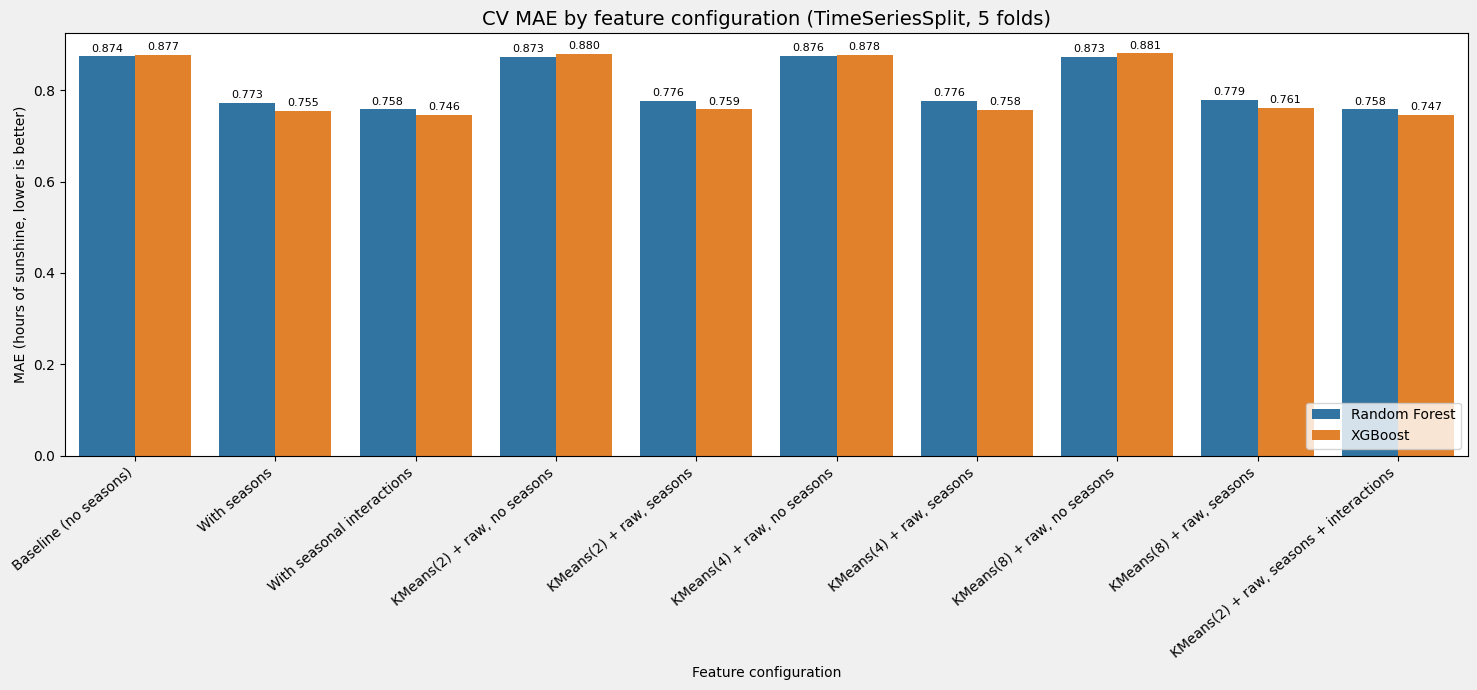

In [8]:
fig, ax = plt.subplots(figsize=(15, 7))
fig.set_facecolor('#f0f0f0')
sns.barplot(data=results_df, x='Features', y='MAE', hue='Model', ax=ax)
ax.legend(loc="lower right")
ax.set_title('CV MAE by feature configuration (TimeSeriesSplit, 5 folds)', fontsize=14)
ax.set_xlabel('Feature configuration')
ax.set_ylabel('MAE (hours of sunshine, lower is better)')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=2, fontsize=8)
plt.setp(ax.get_xticklabels(), rotation=40, ha='right')
fig.tight_layout()
fig.savefig(f'{FIGURES}/model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Model and feature comparison findings

The best models are the XGBoost and Random Forest Regression models trained on the same dataset. They respectively score 0.746 and 0.758 hours (44.76 and 45.48 minutes) as a mean average error across the 5 folds they were test/trained on.

The best performance by both models is on the X_interactions frame, this outlines the seasonal interactions as the most powerful features. The function used to add these features was add_seasonal_interactions() in the src/features.py module. This seperation of seasonal values aided the models just slightly more than the seasonal columns on their own.

The KMeans algorithm was useless. We could predict this from the Inertial/Silhouette chart; the lack of elbow shape in inertia and silhouette score being flat (note the extremely small range of 0.27 to 0.21) tells us that *the variables that guide the weather form a continuum rather than naturallly seperated clumps*. The "categories of day" I had hoped to find overlap into each other.

Looking at KMeans + raw, no seasons for k = 2, 4 and 8, we can see that the choice of k makes negligible difference in the performance of the models. The number of centroids is irrelevant to the chaotic continous distribution that is weather data. 

## 9. Results and Further analysis of the best model

Taking the best performer from the comparison above, we can perform a timesplit and train the model on all the data before 2019, then test it on data from 2019 and onwards. This will give us a better idea of how our model would perform on new data, and worth doing simply because the previous resut of MAE was the average across the 5 folds.

In [ ]:
SPLIT_DATE = pd.Timestamp('2019-01-01')

dates = df.loc[X_interactions.index, 'date']

# slicing would be better but I'll mask since the df not gauranteed to be 100% in order.
train_mask = dates < SPLIT_DATE
X_train, X_test = X_interactions[train_mask], X_interactions[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]
dates_test = dates[~train_mask]

best_pipe = make_xgb_pipe()
best_pipe.fit(X_train, y_train)
best_pred = best_pipe.predict(X_test)
best_name = 'XGBoost'

true_mae = mean_absolute_error(y_test, best_pred)
print(f'Train rows: {len(X_train)}   Test rows: {len(X_test)}')
print(f'2019+ MAE: {true_mae:.3f} hrs  (= {true_mae*60:.1f} minutes)')
print('In comparison, the 5 fold CV MAE was 0.746 hrs (44.76 minutes).')
hld_out = true_mae - results_df.iloc[5]['MAE']
print(f'Hold out generalisation gap: {hld_out:.3f} hrs ({hld_out*60:.1f} mins)')

Train rows: 14587   Test rows: 725
2019+ MAE: 1.147 hrs  (= 68.8 minutes)
In comparison, the 5 fold CV MAE was 0.746 hrs (44.76 minutes).
Hold out gap: 0.401 hrs (24.0 mins)


In [ ]:
# Standard error of the mean on the hold out MAE, SEM = s / sqrt(n), 
# where s = the sample standard deviation of the absolute errors and n = 725
# (Don't know sigma so estimate it as the sample)
abs_errors = np.abs(y_test.values - best_pred)
n = len(abs_errors)
sem = abs_errors.std(ddof=1) / np.sqrt(n)

print(f'Hold out MAE: {true_mae:.3f} +/- {sem:.3f} hrs   (1 SE, n = {n})')
print(f'            = {true_mae*60:.1f} +/- {sem*60:.1f} minutes') 


Hold out MAE: 1.147 ± 0.046 hrs   (1 SE, n = 725)
            = 68.8 ± 2.7 minutes
1.147016324952574


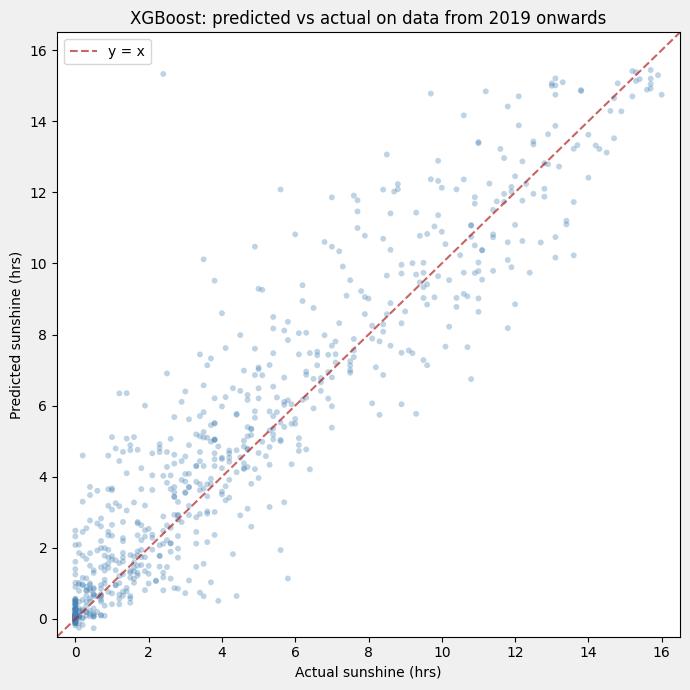

In [10]:
# Predicted vs actual on the 2019 onwards set
fig, ax = plt.subplots(figsize=(7, 7))
fig.set_facecolor('#f0f0f0')
ax.scatter(y_test, best_pred, alpha=0.35, s=18, color='steelblue', edgecolor='none')
lim = (-0.5, max(y_test.max(), best_pred.max()) + 0.5)
ax.plot(lim, lim, ls='--', color='firebrick', alpha=0.7, label='y = x')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('Actual sunshine (hrs)')
ax.set_ylabel('Predicted sunshine (hrs)')
ax.set_title(f'{best_name}: predicted vs actual on data from 2019 onwards')
ax.legend(loc='upper left')
fig.tight_layout()
fig.savefig(f'{FIGURES}/pred_vs_actual.png', dpi=120, bbox_inches='tight')
plt.show()

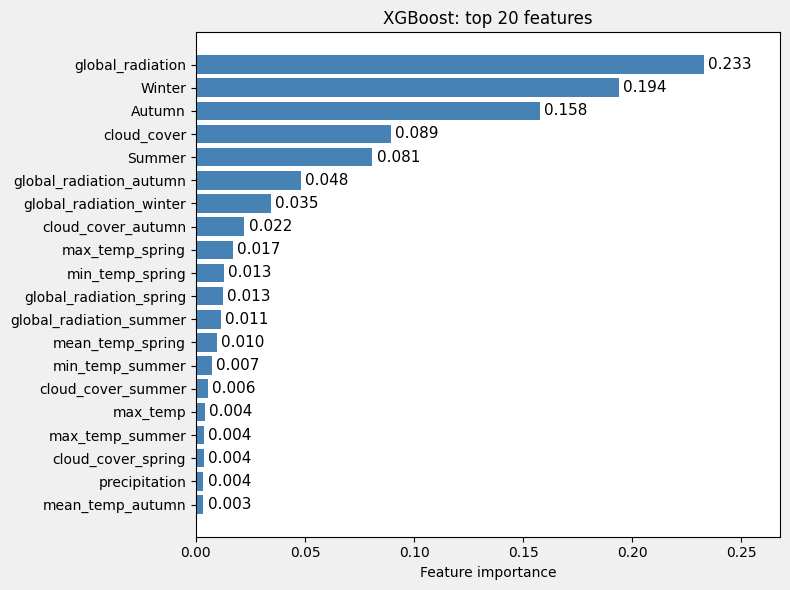

The abscence of Spring here is interesting


In [ ]:
# Most important features
importances = pd.Series(
    best_pipe.named_steps['model'].feature_importances_,
    index=X_train.columns,
).sort_values(ascending=True)

top = importances.tail(20)
fig, ax = plt.subplots(figsize=(8, 6))
fig.set_facecolor('#f0f0f0')
bars = ax.barh(top.index, top.values, color='steelblue')
ax.set_xlabel('Feature importance')
ax.set_title(f'{best_name}: top 20 features')
# value at the end of each bar
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=11)
# extra x room so the labels do not clip off the right edge
ax.set_xlim(0, top.max() * 1.15)
fig.tight_layout()
fig.savefig(f'{FIGURES}/feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

# importance frame
# importances.sort_values(ascending=False).head(20).to_frame('importance').round(4)

The abscence of Spring here is interesting, perhaps because spring is a voilatile season in comparison with the others? But thats guesswork. It seems to have gotten more value from spring's seasonalised individual features than springs category.

No suprises about global radiation and cloud cover dominating.

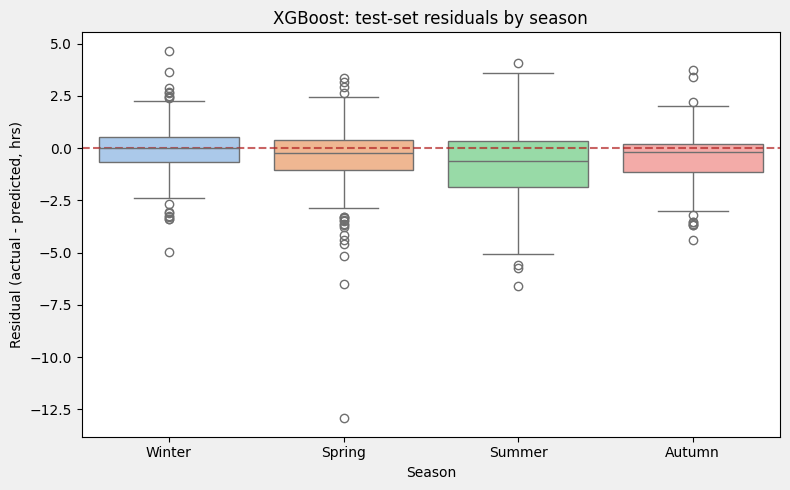

,MAE
season,
Winter,0.948
Spring,1.204
Summer,1.498
Autumn,0.929


In [ ]:
# Residuals by season on 2019+
from features import get_season

residuals = y_test - best_pred
test_season = dates_test.apply(get_season)
resid_df = pd.DataFrame({'residual':residuals.values, 
                         'season': test_season.values})

season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
fig, ax = plt.subplots(figsize=(8, 5))
fig.set_facecolor('#f0f0f0')
sns.boxplot(data=resid_df, 
            x='season',
            y='residual', 
            order=season_order,
            hue='season', 
            palette='pastel',
            legend=False, 
            ax=ax)
ax.axhline(0, ls='--', 
           color='firebrick', 
           alpha=0.7)
ax.set_xlabel('Season')
ax.set_ylabel('Residual (actual - predicted, hrs)')
ax.set_title(f'{best_name}: test-set residuals by season')
fig.tight_layout()
fig.savefig(f'{FIGURES}/residuals_by_season.png',
            dpi=120, 
            bbox_inches='tight')
plt.show()

per_season_mae = resid_df.assign(abs_err=resid_df['residual']\
                                 .abs()).groupby('season')['abs_err']\
                                    .mean().reindex(season_order).round(3)
per_season_mae.to_frame('MAE')

Model performs best in Winter and Autumn, worse in Spring, and worst in Summer. This could simply be the fact that the length of the days is shorter in those seasons so there is a smaller window in which it can "misshoot". The anomaly in Spring where the model predicted the amount of sunshine 12 and a half hours of its actual value made me laugh.  

## 10. Reflections

I wanted to analyse this dataset given the extreme complexity of the weather. Having read James Gleik's popular science book "Chaos" and working through the Non-Linear Dynamics and Chaos textbook by Steven Strogatz, I was curious to see how machine learning models perform when up against chaotic systems. I guess the result of 1 hour and 9 minutes mean average error isn't too bad all things considered. The baseline seasonal average was 3 hours mae, but you could probably trim that down by doing a monthly average amount of sunshine. I never expected gradient boosting for forest regression to perform well here but I guess was hoping to be suprised somewhere.

Of course, in terms of real world use cases for this model, there are few. Predicting the value of sunshine for a day already past when you have all the other metrics of that day has little function. The only one I can think of is to use this model to better impute missing values of sunshine for the sake of better record keeping, but the amount of sunshine is almost never missing so..

It is therefore natural to conclude that the computational cost of this program is not worth the results.

Its worth reiterating that this isn't a forecasting model, but it could be fun to tweak the model and turn it into one by predicting tomorrows sunshine and see how poorly it performs. I'm guessing it would output nonsense with at least 3+ hours of mae, so little use doing that.

The only real suprise was how little effect the temporal leakage had on cross value MAE in section 3. I guess its because of the target distribution changing gradually rather than radically across the years, in combination with the dataset being so large that the averages of the 5 folds were roughly equal to the global mean, meaning leaky imputation changed nothing.